In [2]:
import pandas as pd
import plotly.express as px
import numpy as np

# Dataset: Global Energy Mix by Country and Source
df = pd.read_csv('global_energy_mix.csv')

# Source type mapping — reuse from lecture
source_category = {
    'Coal': 'Fossil', 
    'Oil': 'Fossil', 
    'Natural Gas': 'Fossil',
    'Nuclear': 'Low-carbon', 
    'Hydro': 'Low-carbon',
    'Wind': 'Renewable', 
    'Solar': 'Renewable', 
    'Other Renewables': 'Renewable'
}

df['Source_Type'] = df['Source'].map(source_category)

print(f"Loaded: {len(df)} rows")
print(df.head(10))

Loaded: 103 rows
         Country         Region            Source  Share_pct     TWh  \
0  United States  North America              Coal         10  1015.0   
1  United States  North America               Oil         35  3220.0   
2  United States  North America       Natural Gas         34  3083.0   
3  United States  North America           Nuclear          9   798.0   
4  United States  North America             Hydro          3   339.0   
5  United States  North America              Wind          4   413.0   
6  United States  North America             Solar          3   325.0   
7  United States  North America  Other Renewables          2   229.0   
8          China           Asia              Coal         60  7168.0   
9          China           Asia               Oil         18  1620.0   

  Source_Type  
0      Fossil  
1      Fossil  
2      Fossil  
3  Low-carbon  
4  Low-carbon  
5   Renewable  
6   Renewable  
7   Renewable  
8      Fossil  
9      Fossil  


# Task 1 — Treemap:

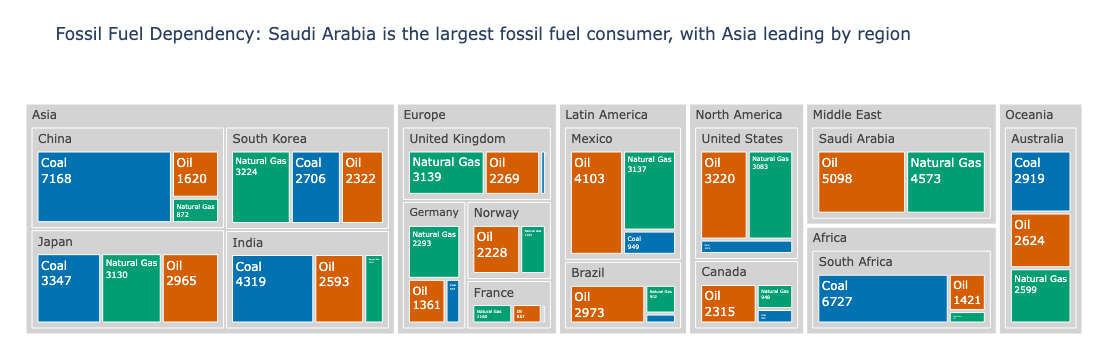

In [4]:


# Filter to fossil sources only
fossil_df = df.loc[df['Source_Type'] == 'Fossil'].copy()

# Find the region and country with the highest fossil fuel usage
region_totals = fossil_df.groupby('Region')['TWh'].sum().sort_values(ascending=False)
country_totals = fossil_df.groupby('Country')['TWh'].sum().sort_values(ascending=False)

top_region = region_totals.index[0]
top_country = country_totals.index[0]

# Create treemap
fig = px.treemap(
    fossil_df,
    path=['Region', 'Country', 'Source'],
    values='TWh',
    color='Source',
    color_discrete_map={
        'Coal': '#0072B2',
        'Oil': '#D55E00',
        'Natural Gas': '#009E73'
    },
    title=f"Fossil Fuel Dependency: {top_country} is the largest fossil fuel consumer, with {top_region} leading by region"
)

fig.update_traces(
    textinfo='label+value',
    hovertemplate='<b>%{label}</b><br>TWh: %{value}<extra></extra>'
)

# Grey out parent nodes: Region and Country levels
source_colors = {
    'Coal': '#0072B2',
    'Oil': '#D55E00',
    'Natural Gas': '#009E73'
}

labels = fig.data[0].labels
new_colors = []

for label in labels:
    if label in source_colors:
        new_colors.append(source_colors[label])
    else:
        new_colors.append('lightgrey')

fig.data[0].marker.colors = new_colors

fig.update_layout(
    margin=dict(t=80, l=20, r=20, b=20)
)

fig.show()

Task 2 — Sunburst: 

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


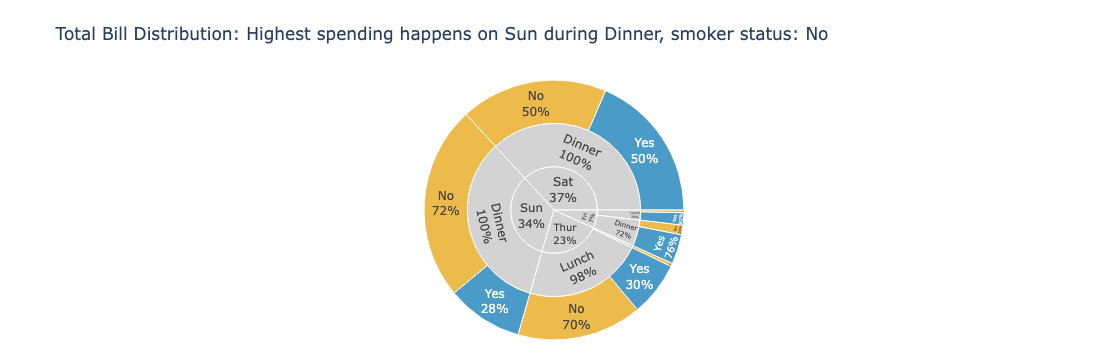

In [20]:
# Load built-in tips dataset
tips = px.data.tips()

# Aggregate total bill by day, time, and smoker status
tips_grouped = (
    tips.groupby(['day', 'time', 'smoker'])['total_bill']
    .sum()
    .reset_index()
)

# Find where the highest spending happens
top_spending = tips_grouped.sort_values('total_bill', ascending=False).iloc[0]

top_day = top_spending['day']
top_time = top_spending['time']
top_smoker = top_spending['smoker']

# Create sunburst chart
fig = px.sunburst(
    tips_grouped,
    path=['day', 'time', 'smoker'],
    values='total_bill',
    color='smoker',
    color_discrete_map={
        'Yes': '#0072B2',
        'No': '#E69F00'
    },
    title=f"Total Bill Distribution: Highest spending happens on {top_day} during {top_time}, smoker status: {top_smoker}"
)

# Use percent parent for text labels
fig.update_traces(
    textinfo='label+percent parent',
    hovertemplate='<b>%{label}</b><br>Total Bill: %{value:.2f}<br>Percent of Parent: %{percentParent:.1%}<extra></extra>'
)

# Grey out parent nodes: day and time levels
labels = fig.data[0].labels

new_colors = []
for label in labels:
    if label == 'Yes':
        new_colors.append('#0072B2')
    elif label == 'No':
        new_colors.append('#E69F00')
    else:
        new_colors.append('lightgrey')

fig.data[0].marker.colors = new_colors

fig.update_layout(
    margin=dict(t=80, l=20, r=20, b=20)
)

fig.show()

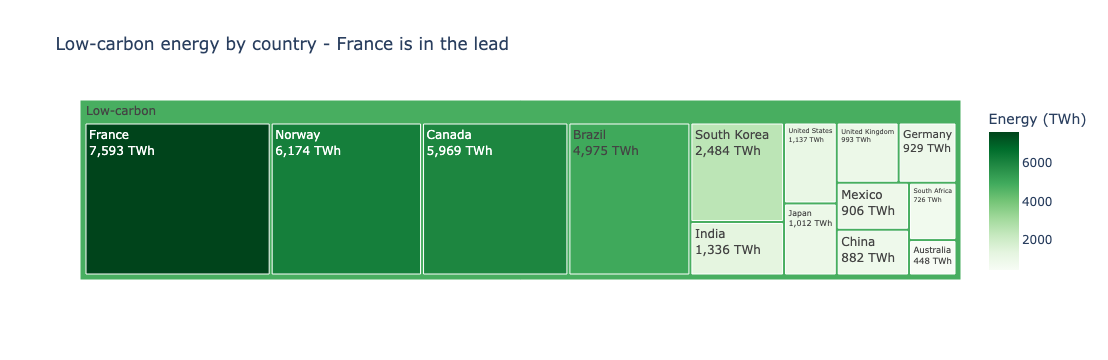

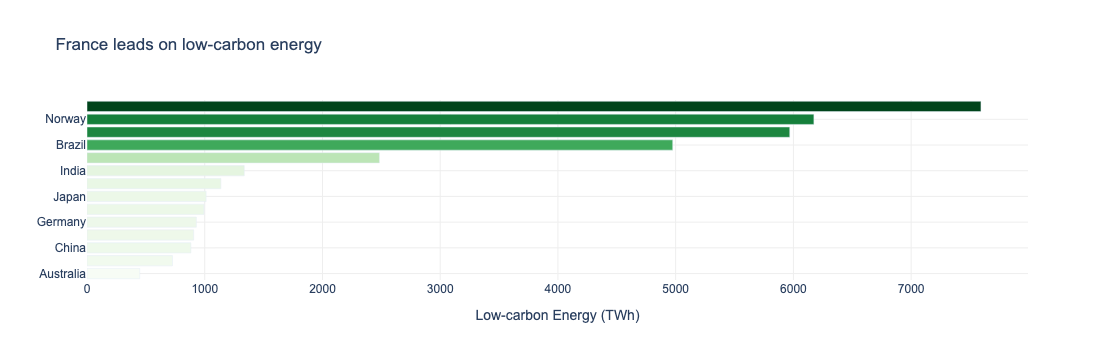

In [34]:
low_carbon = df.loc[df['Source_Type'] == 'Low-carbon'].groupby('Country')['TWh'].sum().reset_index()
low_carbon = low_carbon.sort_values('TWh', ascending=True) # Sort for bar chart
 
# Determine the leading country for titles
leading_country = low_carbon.sort_values('TWh', ascending=False).iloc[0]['Country']
 
low_carbon['All'] = 'Low-carbon'   # dummy root node with a meaningful label, as per prompt
 
fig_tree = px.treemap(
    low_carbon,
    path=['All', 'Country'],       # All → Country
    values='TWh',
    color='TWh',
    color_continuous_scale='Greens',
    title=f"Low-carbon energy by country - {leading_country} is in the lead", # Updated title
    labels={'TWh': 'Energy (TWh)'},
)
fig_tree.update_traces(
    texttemplate='%{label}<br>%{value:,.0f} TWh',
    hovertemplate='<b>%{label}</b><br>%{value:,.0f} TWh<extra></extra>',
    root_color='white',
)
 
fig_tree.show()
 
# Bar chart version
fig_bar = px.bar(
    low_carbon,
    x='TWh',
    y='Country',
    orientation='h',
    color='TWh',
    color_continuous_scale='Greens',
    title=f"{leading_country} leads on low-carbon energy", # Updated title
    labels={'TWh': 'Low-carbon Energy (TWh)', 'Country': ''}, # Updated label
)
fig_bar.update_layout(
    plot_bgcolor='white',
    paper_bgcolor='white',
    font=dict(family='Arial', size=12),
    coloraxis_showscale=False,
)
fig_bar.update_xaxes(gridcolor='#EEEEEE')
fig_bar.update_yaxes(gridcolor='#EEEEEE')
fig_bar.show()
 